In [ ]:
from nodes.agent_state import AgentState, llm
from nodes.router import router_node, route_after_router
from nodes.lawyer import lawyer_node
from nodes.finance import financial_node
from nodes.property import property_manager_node, tenant_extractor_node
from nodes.assistant import assistant_node
from nodes.work_talk import work_small_talk_node, route_work_small_talk
from nodes.combiner import combiner_node
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.sqlite import SqliteSaver
from langchain_core.messages import HumanMessage
from settings import Settings

settings = Settings()

In [3]:
builder = StateGraph(AgentState)

builder.add_node("work_small_talk_node", work_small_talk_node)
builder.add_node("router_node", router_node)
builder.add_node("lawyer_node", lawyer_node)
builder.add_node("financial_node", financial_node)
builder.add_node("tenant_extractor_node", tenant_extractor_node)
builder.add_node("property_manager_node", property_manager_node)
builder.add_node("assistant_node", assistant_node)
builder.add_node("combiner_node", combiner_node)

builder.add_edge(START, "work_small_talk_node")

# Send запускает ноды параллельно
builder.add_conditional_edges(
    "work_small_talk_node",
    route_work_small_talk,
    {
        "router_node": "router_node",
        "assistant_node": "assistant_node"
    }
)

builder.add_conditional_edges(
    "router_node",
    route_after_router,
    {
        "lawyer_node": "lawyer_node",
        "financial_node": "financial_node",
        "property_manager_node": "tenant_extractor_node",
    }
)

builder.add_edge("tenant_extractor_node", "property_manager_node")

builder.add_edge("lawyer_node", "combiner_node")
builder.add_edge("financial_node", "combiner_node")
builder.add_edge("property_manager_node", "combiner_node")
builder.add_edge("assistant_node", "combiner_node")
builder.add_edge("combiner_node", END)

graph = builder.compile()

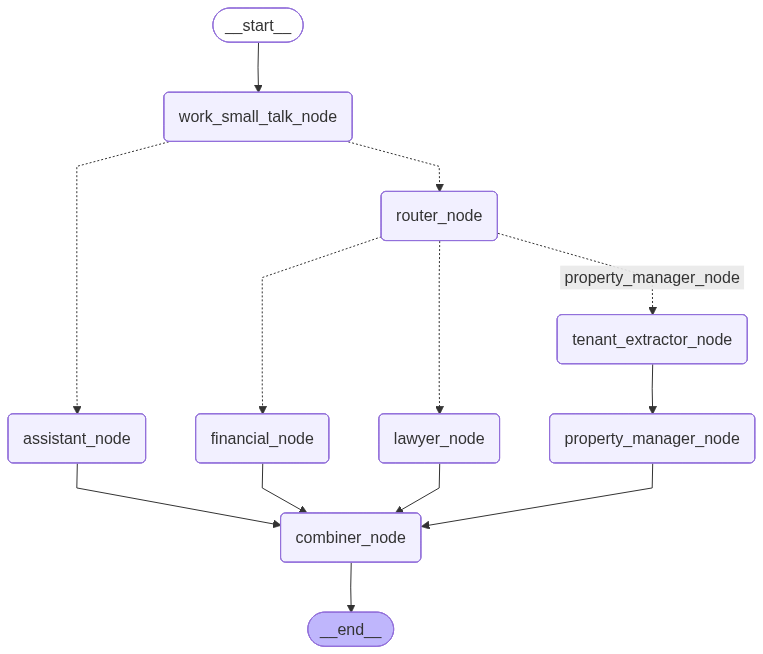

In [3]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print(graph.get_graph().draw_ascii())

# Блок тестирования Роутинга и work/small talk

In [4]:
routing_tests = [
    # (запрос, ожидаемая нода)
    ("Когда заканчивается договор с Озоном?", "lawyer", False),
    ("Рассчитай налог УСН за квартал, доход 500000 руб", "financial", False),
    ("Когда последний раз меняли замок у Гемотеста?", "property_manager", False),
    ("Как дела?", "property_manager", True),
    ("", "property_manager", True),  # fallback
    ("Как дела? Кстати, какая у нас арендная плата у Ozon?", "lawyer", True)
]

with SqliteSaver.from_conn_string("memory.db") as checkpointer:
    graph = builder.compile(checkpointer=checkpointer)
    
    for query, expected_route, use_assistant in routing_tests:
        result = graph.invoke(
            {"messages": [HumanMessage(content=query)], "use_assistant": False},
            config={"configurable": {"thread_id": "test_routing"}}
        )
        status = "✅" if result["next_step"] == expected_route and result["use_assistant"] == use_assistant else "❌"
        print(f"{status} Ожидали: {expected_route}, получили: {result['next_step']}")
        print(f"   Запрос: {query}")
        print(f"   Ответ: {result["messages"][-1].content}")
        print()

lawyer_node
✅ Ожидали: lawyer, получили: lawyer
   Запрос: Когда заканчивается договор с Озоном?
   Ответ: По **Договору аренды № 12/2023** с ООО «Озон Логистика» срок аренды установлен **с 01.02.2023 по 31.01.2026**.

✅ **Договор заканчивается 31.01.2026.**

financial_node
✅ Ожидали: financial, получили: financial
   Запрос: Рассчитай налог УСН за квартал, доход 500000 руб
   Ответ: **Дано:** доход за квартал = **500 000 руб.**, УСН **6%**.

**Расчет:**
1) Налог = 500 000 × 6%  
2) Налог = 500 000 × 0,06 = **30 000 руб.**

✅ **Налог УСН за квартал: 30 000 руб.**

property_manager_node
✅ Ожидали: property_manager, получили: property_manager
   Запрос: Когда последний раз меняли замок у Гемотеста?
   Ответ: Пока в нашей истории переписки нет данных по объекту «Гемотест» и по замене замка (дата/акт/исполнитель).  

Уточните, пожалуйста:  
1) адрес объекта или номер помещения, где находится «Гемотест»;  
2) если есть — номер договора/лицевого счета.  

После этого смогу проверить по вашим

# Блок тестирования RAG юриста

In [7]:
lawyer_tests = [
    {
        "query": "Какой штраф за досрочный выезд у Вайлдберриз?",
        "must_contain": ["6", "месяч"],
    },
    {
        "query": "Когда заканчивается договор с Гемотестом?",
        "must_contain": ["14.03.2025"],
    },
    {
        "query": "Какая арендная ставка у Озона?",
        "must_contain": ["1 200"],
    },
    {
        "query": "Есть ли в договорах пункт про НДС?",
        "must_contain": ["УСН", "не облагается"],
    },
]

with SqliteSaver.from_conn_string("memory.db") as checkpointer:
    graph = builder.compile(checkpointer=checkpointer)

    for test in lawyer_tests:
        result = graph.invoke(
            {"messages": [HumanMessage(content=test["query"])]},
            config={"configurable": {"thread_id": "test_lawyer"}}
        )
        answer = result["messages"][-1].content.lower()
        hits = [kw for kw in test["must_contain"] if kw.lower() in answer]
        status = "✅" if len(hits) == len(test["must_contain"]) else "❌"
        print(f"{status} {test['query']}")
        print(f"   Найдено ключевых слов: {hits}/{test['must_contain']}")
        print(f"   Ответ: {answer[:150]}...")
        print()

lawyer_node
✅ Какой штраф за досрочный выезд у Вайлдберриз?
   Найдено ключевых слов: ['6', 'месяч']/['6', 'месяч']
   Ответ: по **договору аренды № 3/2024** (арендатор **ооо “вайлдберриз”**) штраф за досрочное расторжение/выезд составляет: **6 месячных платежей**....

lawyer_node
✅ Когда заканчивается договор с Гемотестом?
   Найдено ключевых слов: ['14.03.2025']/['14.03.2025']
   Ответ: по **договору аренды № 8/2022** с ооо «гемотест» срок аренды установлен **с 15.03.2022 по 14.03.2025**.  

✅ **договор заканчивается 14.03.2025.**...

lawyer_node
✅ Какая арендная ставка у Озона?
   Найдено ключевых слов: ['1 200']/['1 200']
   Ответ: по **договору аренды № 12/2023** арендная ставка для **ооо «озон логистика»** составляет **1 200 руб. за 1 кв.м в месяц**....

lawyer_node
✅ Есть ли в договорах пункт про НДС?
   Найдено ключевых слов: ['УСН', 'не облагается']/['УСН', 'не облагается']
   Ответ: да, в обоих договорах есть условие про ндс:

- **договор аренды № 8/2022**: указано, что **ндс

In [9]:
with SqliteSaver.from_conn_string("memory.db") as checkpointer:
    graph = builder.compile(checkpointer=checkpointer)

    # Имитируем историю по арендатору Гемотест
    config = {"configurable": {"thread_id": "hemotest"}}

    events = [
        "Зафиксируй: 15 января провели поверку счётчиков в помещении Гемотест",
        "Зафиксируй: 20 января Гемотест пожаловался на протечку в подсобке",
        "Зафиксируй: 25 января протечку в Гемотест устранили, подрядчик Иванов С.А.",
        "Зафиксируй: 1 февраля Гемотест заявил о желании изменить высеку",
        "Зафиксируй: 15 февраля вывеска Гемотеста была заменена",
        "Поверка счетчиков и вайлдбериз была 2 февраля",
        "Озон обновил свою вывеску 5 марта",
        "Когда была последняя поверка счётчиков у Гемотеста?"
    ]

    for event in events:
        result = graph.invoke(
            {"messages": [HumanMessage(content=event)]},
            config=config
        )
        print(f"Вопрос: {event}")
        print(f"Ответ:  {result['messages'][-1].content}")
        print("-" * 60)

property_manager_node
Вопрос: Зафиксируй: 15 января провели поверку счётчиков в помещении Гемотест
Ответ:  Зафиксировал в истории взаимодействия с арендатором: **15 января** в помещении **«Гемотест»** проведена **поверка счётчиков**.
------------------------------------------------------------
property_manager_node
Вопрос: Зафиксируй: 20 января Гемотест пожаловался на протечку в подсобке
Ответ:  Зафиксировал в истории взаимодействия с арендатором: **20 января** арендатор **«Гемотест»** **пожаловался на протечку в подсобке**.
------------------------------------------------------------
property_manager_node
Вопрос: Зафиксируй: 25 января протечку в Гемотест устранили, подрядчик Иванов С.А.
Ответ:  Зафиксировал в истории взаимодействия с арендатором: **25 января** в помещении **«Гемотест»** **устранили протечку**, работы выполнил **подрядчик Иванов С.А.**
------------------------------------------------------------
property_manager_node
Вопрос: Зафиксируй: 1 февраля Гемотест заявил о жела

In [4]:
#при запуске с 0 память подтягиваается
with SqliteSaver.from_conn_string("memory.db") as checkpointer:
    graph = builder.compile(checkpointer=checkpointer)

    # Имитируем историю по арендатору Гемотест
    config = {"configurable": {"thread_id": "hemotest"}}

    events = [
        "Когда была последняя поверка счётчиков у Гемотеста?",
    ]

    for event in events:
        result = graph.invoke(
            {"messages": [HumanMessage(content=event)]},
            config=config
        )
        print(f"Вопрос: {event}")
        print(f"Ответ:  {result['messages'][-1].content}")
        print("-" * 60)

property_manager_node
Вопрос: Когда была последняя поверка счётчиков у Гемотеста?
Ответ:  Последняя поверка счётчиков у арендатора **«Гемотест»** была **15 января** (в помещении «Гемотест» проведена поверка счётчиков).
------------------------------------------------------------


In [ ]:
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, RemoveMessage

#суммаризация, оставим на потом
def summarize_history(messages: list) -> str:
    all_text = ""
    for message in messages:
        message_type = "Human" if isinstance(message, HumanMessage) else "Agent"
        all_text += f"{message_type}: {message.content} \n"
    response = llm.invoke([
        SystemMessage(content="Сожми диалог, выделив ключевые события и договоренности"),
        HumanMessage(content=f"Суммаризируй:\n{all_text}")
    ])
    return response.content

def summary_node(state: AgentState) -> dict:
    messages = state["messages"]
    last_message = messages[-1]

    if len(messages) > settings.max_history_messages:
        summary = summarize_history(messages[:-1])
        remove_old = [RemoveMessage(id=m.id) for m in messages[:-1]]
        summary_message = SystemMessage(content=f"Сводка предыдущих событий: {summary}")
        result = manager.invoke({"history": summary, "query": last_message})
        return {
            "messages": remove_old + [summary_message, AIMessage(content=result.content)]
        }
    else:
        result = manager.invoke({"history": messages, "query": last_message})
        return {
            "messages": [AIMessage(content=result.content)]
            }